In [1]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def filter_score(smiles, cache_dict, length):
    values = cache_dict.get(smiles)
    if values:
        if abs(values[0]) == 10000.0:
            return [float("nan")]*length
        else:
            return values
    else:
        return [float("nan")]*length

""" Scaler scores """
def extract_score(target_file, cache_dict, predict_dict, target_columns):
    with open(target_file, "r") as g:
        data = g.readlines()
    smiles_list = [line.split(", ")[1] for line in data]
    
    predict_scores = [filter_score(smiles, predict_dict, len(target_columns)) for smiles in smiles_list]
    predict_target_columns = ["pred_"+ target for target in target_columns]
    df1 = pd.DataFrame(predict_scores, columns=predict_target_columns)
       
    calc_scores = [filter_score(smiles, cache_dict, len(target_columns)) for smiles in smiles_list]
    calc_predict_target_columns = ["calc_"+ target for target in target_columns]
    df2 = pd.DataFrame(calc_scores, columns=calc_predict_target_columns)
    df = pd.concat([df1, df2], axis=1)

    return df

def extract_benchmark_dict(sub_dir_name, parent_dir, cache_dict, predict_dict, num_fold, target_columns):
    benchmark_dict = {}
    for sub_dir in sub_dir_name:
        real_dir = os.path.join(parent_dir, sub_dir)
        sub_data = pd.DataFrame()
        for fold in range(1, num_fold+1):
            target_file = os.path.join(real_dir+"_{}".format(fold), "generation_all_best.txt")
            df = extract_score(target_file, cache_dict, predict_dict, target_columns)
            rename_dict = {score: score+"_{}".format(fold) for score in df.columns}
            df = df.rename(columns=rename_dict)
            sub_data = pd.concat([sub_data, df], axis=1)
        benchmark_dict.update({sub_dir: sub_data})
    return benchmark_dict

def process_lines(data, target_columns):
    means = data[target_columns].mean(axis=1)
    stds = data[target_columns].std(axis=1)
    return means, stds

def create_single_score_plot(benchmark_dict, sub_dir_name, save_dir, num_fold, num_generation, color_dict, target,
                         alpha_span = 0.25, center_linewidth = 0.75, label_fontsize = 12, legend_fontsize = 9):
    # plot scaler scores
    x = [i for i in range(1, num_generation+1)]

    plt.figure(dpi=100)
    for sub_dir in sub_dir_name:
        data = benchmark_dict[sub_dir]

        pred_fitness_columns = ["pred_{}_{}".format(target, fold) for fold in range(1, num_fold+1)]
        means, stds = process_lines(data, pred_fitness_columns)
        plt.plot(x, means, color=color_dict[sub_dir+"_pred"], label=sub_dir+" (surrogate)", linewidth=center_linewidth*2)
        positive = means + stds * 1.96 / np.sqrt(num_fold)
        negative = means - stds * 1.96 / np.sqrt(num_fold)
        plt.plot(x, positive, color=color_dict[sub_dir+"_pred"], alpha=alpha_span, linewidth=0.1)
        plt.plot(x, negative, color=color_dict[sub_dir+"_pred"], alpha=alpha_span, linewidth=0.1)
        plt.fill_between(x,positive,negative, color=color_dict[sub_dir+"_pred"], alpha=alpha_span)

        calc_fitness_columns = ["calc_{}_{}".format(target, fold) for fold in range(1, num_fold+1)]
        means, stds = process_lines(data, calc_fitness_columns)
        plt.plot(x, means, color=color_dict[sub_dir+"_calc"], label=sub_dir+" (actual)", linewidth=center_linewidth*2)
        positive = means + stds * 1.96 / np.sqrt(num_fold)
        negative = means - stds * 1.96 / np.sqrt(num_fold)
        plt.plot(x, positive, color=color_dict[sub_dir+"_calc"], alpha=alpha_span, linewidth=0.1)
        plt.plot(x, negative, color=color_dict[sub_dir+"_calc"], alpha=alpha_span, linewidth=0.1)
        plt.fill_between(x,positive,negative, color=color_dict[sub_dir+"_calc"], alpha=alpha_span)
    
    plt.grid(color = 'gray', linestyle = '-', linewidth = 0.25)
    # plt.title("Scaler Scores",fontsize=label_fontsize)
    plt.legend(fontsize=legend_fontsize)
    plt.xlabel("Generation", fontsize=label_fontsize)
    plt.ylabel("{}".format(target), fontsize=label_fontsize)
    plt.savefig(os.path.join(save_dir, target+".svg"), format='svg')


## Docking

In [2]:
calc_data_path = "./RESULTS/docking/cal_results.csv"
predict_data_path = "./RESULTS/docking/predict_results.csv"
target_columns = ["1syh score", "4lde score", "6y2f score"]
score_columns = ["1syh score", "4lde score", "6y2f score", "scaler score", "predicted_fitness"]
scaler_dict = {"1syh score": (-2.832, 8.928), "4lde score": (-7.547, 1.617), "6y2f score": (-5.528, 0.997)}
cutoff_dict = {"1syh score": -7.7, "4lde score": -9.3, "6y2f score": -6.8}
target_objective = {"1syh score":"minimize", 
                    "4lde score":"minimize", 
                    "6y2f score":"minimize"}

dataset = "docking"
parent_dir = "RESULTS/{}".format(dataset)
with open(os.path.join(parent_dir, "cal_dict.pkl"), "rb") as f:
    cache_dict = pickle.load(f)
with open(os.path.join(parent_dir, "predict_dict.pkl"), "rb") as f:
    predict_dict = pickle.load(f)

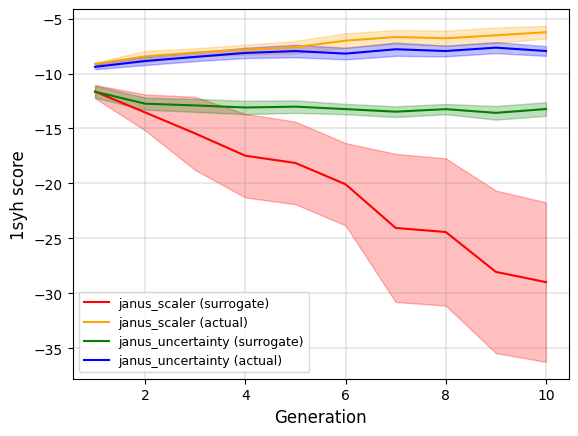

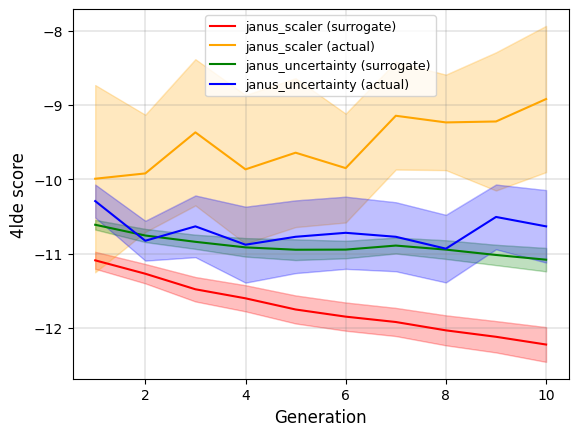

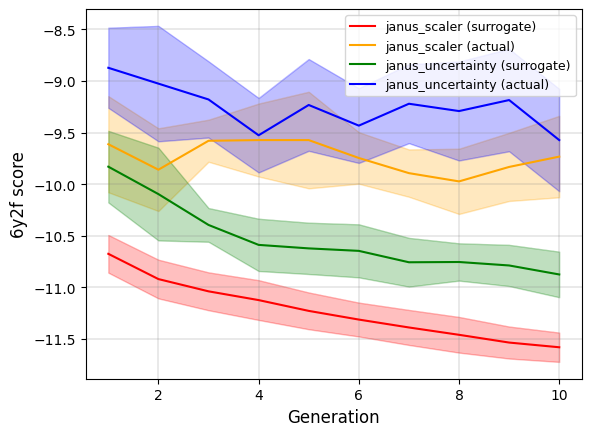

In [3]:
dataset = "docking"
single_objective_list = ["1syh", "4lde", "6y2f"]
target_columns = ["1syh score", "4lde score", "6y2f score"]
""" Dataset setting """
sub_dir_name = ["janus_scaler", "janus_uncertainty"]
save_dir = "figures/plot_iteration_single_objective/{}".format(dataset)
os.makedirs(save_dir, exist_ok=True)
num_fold = 15
num_generation = 10
""" Plot setting """
color_dict = {"janus_scaler_pred":"red", "janus_uncertainty_pred": "green", "janus_scaler_calc":"orange", "janus_uncertainty_calc": "blue"}
###############################################
for single_objective, target in zip(single_objective_list, target_columns):
    parent_dir = "RESULTS/{}_{}".format(dataset, single_objective)
    benchmark_dict = extract_benchmark_dict(sub_dir_name, parent_dir, cache_dict, predict_dict, num_fold, target_columns)
    create_single_score_plot(benchmark_dict, sub_dir_name, save_dir, num_fold, num_generation, color_dict, target)

## Organic Emitter

In [4]:
target_columns = ["singlet-triplet value", "oscillator strength", "abs_diff_vee"]
target_objective = {"singlet-triplet value":"maximize", 
                    "oscillator strength":"maximize", 
                    "abs_diff_vee":"minimize"}

dataset = "organic_emitter"
parent_dir = "RESULTS/{}".format(dataset)
with open(os.path.join(parent_dir, "cal_dict.pkl"), "rb") as f:
    cache_dict = pickle.load(f)
with open(os.path.join(parent_dir, "predict_dict.pkl"), "rb") as f:
    predict_dict = pickle.load(f)

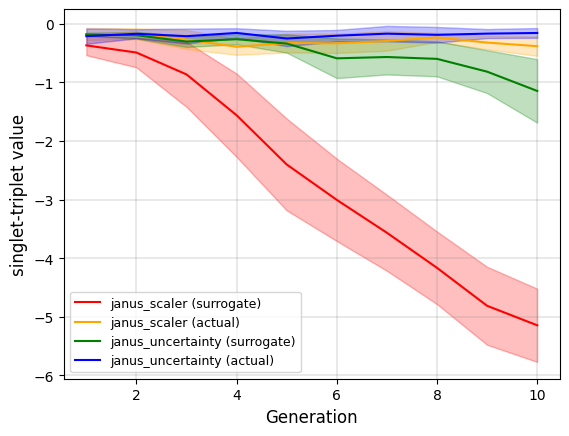

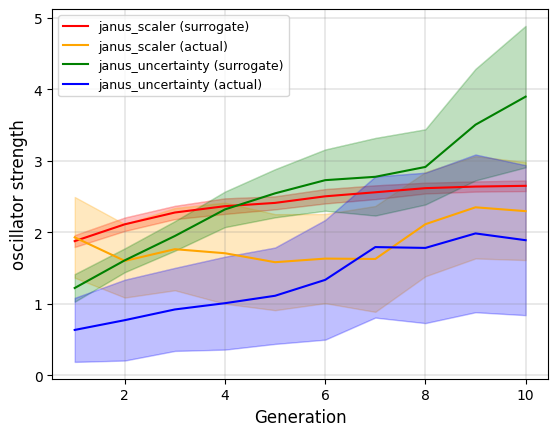

In [5]:
single_objective_list = ["stv", "os", "abs_diff_vee"]
target_columns = ["singlet-triplet value", "oscillator strength", "abs_diff_vee"]
""" Dataset setting """
sub_dir_name = ["janus_scaler", "janus_uncertainty"]
save_dir = "figures/plot_iteration_single_objective/{}".format(dataset)
os.makedirs(save_dir, exist_ok=True)
num_fold = 15
num_generation = 10
""" Plot setting """
color_dict = {"janus_scaler_pred":"red", "janus_uncertainty_pred": "green", "janus_scaler_calc":"orange", "janus_uncertainty_calc": "blue"}
###############################################
for single_objective, target in zip(single_objective_list, target_columns):
    if target == "abs_diff_vee":
        break
    parent_dir = "RESULTS/{}_{}".format(dataset, single_objective)
    benchmark_dict = extract_benchmark_dict(sub_dir_name, parent_dir, cache_dict, predict_dict, num_fold, target_columns)
    create_single_score_plot(benchmark_dict, sub_dir_name, save_dir, num_fold, num_generation, color_dict, target)

## Reactivity

In [6]:
target_columns = ["activation_energy", "reaction_energy"]
target_objective = {"activation":"minimize", 
                    "reaction_energy":"minimize",}

dataset = "reactivity"
parent_dir = "RESULTS/{}".format(dataset)
with open(os.path.join(parent_dir, "cal_dict.pkl"), "rb") as f:
    cache_dict = pickle.load(f)
with open(os.path.join(parent_dir, "predict_dict.pkl"), "rb") as f:
    predict_dict = pickle.load(f)

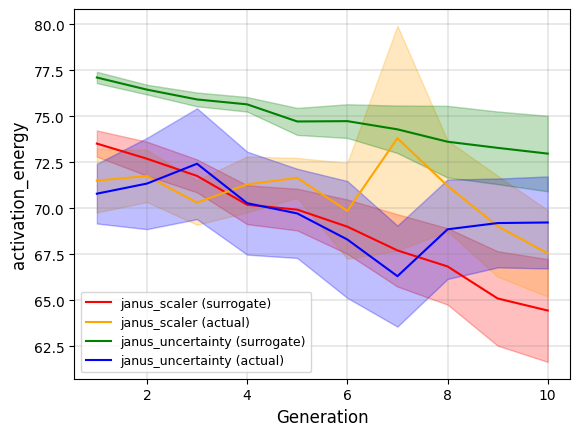

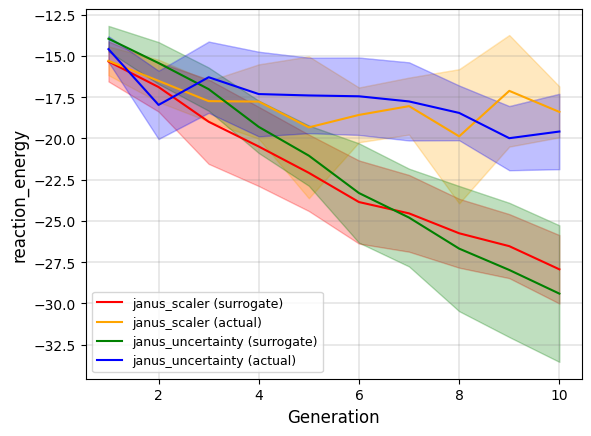

In [7]:
single_objective_list = ["activation_energy", "reaction_energy"]
target_columns = ["activation_energy", "reaction_energy"]
""" Dataset setting """
sub_dir_name = ["janus_scaler", "janus_uncertainty"]
save_dir = "figures/plot_iteration_single_objective/{}".format(dataset)
os.makedirs(save_dir, exist_ok=True)
num_fold = 15
num_generation = 10
""" Plot setting """
color_dict = {"janus_scaler_pred":"red", "janus_uncertainty_pred": "green", "janus_scaler_calc":"orange", "janus_uncertainty_calc": "blue"}
###############################################
for single_objective, target in zip(single_objective_list, target_columns):
    parent_dir = "RESULTS/{}_{}".format(dataset, single_objective)
    benchmark_dict = extract_benchmark_dict(sub_dir_name, parent_dir, cache_dict, predict_dict, num_fold, target_columns)
    create_single_score_plot(benchmark_dict, sub_dir_name, save_dir, num_fold, num_generation, color_dict, target)